In [1]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for parent in v._parents:
                edges.add((parent, v))
                build(parent)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) 
    
    for n in nodes:
        # Handle array data; using str to convert array to string, and taking only the first few elements or use .shape
        data_str = str(n.data)
        if isinstance(n, int):
            grad_str = str(n)
        elif isinstance(n, LTensor):
            grad_str = str(n.grad)
        else:
            print(n)
        # grad_str = str(n) if isinstance(n, int) else str(n.grad.data)
        label_str = f"data: {data_str} | grad: {grad_str}"
        dot.node(name=str(id(n)), label=label_str, shape='record')
        
        if n._op:
            op_label = n._op
            dot.node(name=str(id(n)) + op_label, label=op_label)
            dot.edge(str(id(n)) + op_label, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [89]:
class LTensor:

    def __init__(self, data, _parents=(), _op=''):
        # data attributes
        self.data = np.atleast_1d(data)
        self.dtype = self.data.dtype
        self.shape = self.data.shape
        # autodiff attributes
        self.grad = np.zeros(self.shape)
        self._op = _op
        self._backward = lambda: None
        self._parents = set(_parents)

    def __add__(self, other):
        other = other if isinstance(other, LTensor) else LTensor(other)
        out = LTensor(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += np.ones(self.shape) * out.grad
            other.grad += np.ones(other.shape) * out.grad
        out._backward = _backward

        return out

    def dot(self, other):
        other = other if isinstance(other, LTensor) else LTensor(other)
        out = LTensor(self.data @ other.data, (self, other), 'dot')

        def _backward():
            self.grad = np.outer(out.grad, other.data) 
            other.grad = self.data.T.dot(out.grad) if out.grad.size > 1 else self.data * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        out = LTensor(np.tanh(self.data), (self, ), 'tanh')

        def _backward():
            self.grad = (1 - np.tanh(self.data)**2) * out.grad
        out._backward = _backward

        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for parent in v._parents:
                    build_topo(parent)
                topo.append(v)
        build_topo(self)

        self.grad = np.ones(self.shape)
        for v in reversed(topo):
            v._backward()

    def __neg__(self):
        return self * (-1)

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return -self + other

    def __radd__(self, other):
        return self + other
        
    def __repr__(self):
        data_str = np.array2string(self.data, separator=', ')
        indent = ' ' * 13  # Adjust the number of spaces to align rows
        data_str = data_str.replace('\n', '\n' + indent)
        return f"LTensor(data={data_str})"


In [94]:
x = LTensor([2.0, 0.0])
w = LTensor([[-3.0, 1.0], [2.0, 1.5]])
ow = LTensor([-3.0, 1.0])
b = LTensor([5.5, -3.5])
ob = LTensor([-2.5])

n = w.dot(x)

z = n + b

ox = z.tanh()

on = ow.dot(ox)

oz = on + ob

oo = oz.tanh()


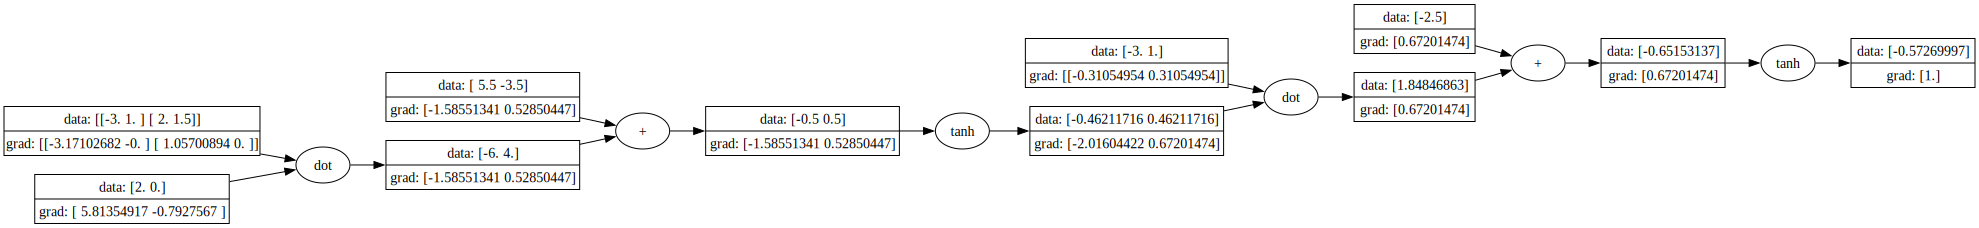

In [97]:
draw_dot(oo)

In [96]:
oo.backward()